![logo](../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Evaluating growth periods for wheat based on temperatures in seasonal subdaily forecast

Production date: 25.03.2026

Produced by: Johanna Tjernström, Johannes Langvatn

## 🌍 Use case: Investigation of minimum and maximum temperature in relation to optimal growing conditions for common crops.

## ❓ Quality assessment question
* **Can seasonal forecasts of minimum and maximum temperature be used to draw conclusions about growth conditions for common crops?**
* **How do long term temporal trends impact the growing season?**
* **Can seasonal forecasts of minimum and maximum temperature be used to draw conclusions about optimal planting dates for common crops?**

One important factor for determining daily crop growth and in extension the total crop yield is the daily variations of temperature during the growth period. Typically, when considering the trends in crop yield in relation to changing temperature trends due to climate change, average daily temperature is used. However it is also important to consider the daily range of temperature which can be done by looking at the maximum and minimum temperatures and the diurnal temperature range given by their difference (DTR=Tmax-Tmin). ([Lobell, David B. (2007) \[1\]](https://doi.org/10.1016/j.agrformet.2007.05.002))

This notebook considers the optimal growing temperatures for spring wheat planted in central Europe, looking both at the effectiveness of seasonal forecasts in drawing conclusions about growth conditions for crops, and also how long term temperature trends in minimum and maximum temperature impact the growing season. This is done through looking at the subdaily minimum and maximum temperature in relation to the growth period and growing requirements for spring wheat. 

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* For the 2025 period, considering spring wheat with a planting date in April conclusions can be drawn based on the seasonal forecast, that April is a decent planting month for good growth conditions, and that warmer temperatures towards the end of the period may impact final yield. 
* No concrete conclusions can be drawn from the interannual variability of minimum and maximum temperature, there is no clear trend between years and the amount of noise is too large to draw conclusions about agreement between the seasonal forecast and ERA5.
* There is a somewhat visible trend in the number of days falling outside optimal growth conditions based on the hindcast, characterised by a faint increase in the number of days with conditions warmer than the higher threshold for optimal growth. However, there is little agreement between the hindcast and ERA5.
```

## 📋 Methodology

This notebook provides a usecase for using the subdaily minimum and maximum temperatures from [Seasonal forecast daily and subdaily data on single levels](https://doi.org/10.24381/cds.181d637e) and [ERA5 Reanalysis](https://doi.org/10.24381/cds.adbb2d47). 

The forecast data for the target period is debiased using the hindcast period, with a trend preserving tool ibicus ([Spuler, et al. (2024) \[2\]](https://doi.org/10.5194/gmd-17-1249-2024)). Both the hindcast period and the forecast period are used in visualisations.

A growth window was also established, based on the plant date and the growth time for wheat, as well as the optimal daily temperature window for growth, stated to be between 15 and 20 degrees celsius.

Using this data plots were generated both to try and assess temporal trends, for example looking at the interannual variability, looking both at the hindcast and ERA5. As well as generating plots for each year of the hindcast period showing maximum and minimum temperature in relation to the growth window. 

The number of days during the growing period outside that optimal temperature window was also calculated both for the hindcast and also for ERA5 to illustrate a possible trend in the number of days a year spent outside of optimal growing conditions. 

Lastly a plot is generated with all of the different thresholds for crop growth, the optimal growth window is added, but also a minimum temperature for measurable growth and also an indicator for frost risk. The debiased forecast period is plotted with all members and ensemble mean. The climatology, taken from the hindcast period is also added as a shaded region. 

**[](seasonal_seasonal-original-single-levels_resolution_q08:section-1)**
 * Choose a selection of forecast systems and model version for the hindcast period and for the target forecast period, based on the year and planting month you want to explore
 * Choose period, matching both hindcast and forecast, for ERA5

**[](seasonal_seasonal-original-single-levels_resolution_q08:section-2)**
 * The forecast period is debiased using the hindcast data using a trend preserving method.
 * Both the debiased data, and the hindcast data are saved.

**[](seasonal_seasonal-original-single-levels_resolution_q08:section-3)**
 * The interannual variability is plotted for a selected month for the hindcast period and era5
 * The minimum and maximum temperature is also plotted for ERA5 for the hindcast period, with a window for growing period and optimal growth temperatures to indicate temperature trends from year to year.
 * The number of days of the growing period that are outside the optimal temperature range is also visualized for both the hindcast period and ERA5

**[](seasonal_seasonal-original-single-levels_resolution_q08:section-4)**
 * The debiased forecast, with all ensemble members is plotted for the whole season, with the climatology taken from the hindcast over the growth window, based on the given start month and the growth time for spring wheat, as well as the optimal growth temperature window, the frost risk and minimum temperature for measurable growth.

**[](seasonal_seasonal-original-single-levels_resolution_q08:section-5)**
   
**Key limitations:**
* Focusing just on temperature does not provide the full picture in terms of crop growth and yield since that is also heavily dependent on other conditions such as precipitation.
* The temperatures used as a baseline for growing conditions outlined on the FAO website [[3]](https://www.fao.org/land-water/databases-and-software/crop-information/wheat/en/) are specified as mean daily temperature, and thus cannot be directly compared to the maximum and minimum temperature.
* This notebook assumes the bias to be similar in all realizations, as the debiasing method is run for the 0th realization and then this computed bias is subtracted from the other realizations.
* This notebook does not make a distinction between arable and non-arable land.

## 📈 Analysis and results

(seasonal_seasonal-original-single-levels_resolution_q08:section-1)=
### 1. Download data and select region and crop of interest

Import packages to be used in the notebook

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from c3s_eqc_automatic_quality_control import diagnostics, download, utils
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.colors as col
from ibicus.debias import CDFt
plt.style.use("seaborn-v0_8-notebook")

Define functions to be used later in the plotting

In [2]:
def get_plant_month(year, month):
    return pd.Timestamp(str(year) + f"-0{month}-01")

def units_kelvin_to_celsius_era5(ds):
    ds.t2m.attrs["GRIB_units"] = "°C"
    ds.t2m.attrs["units"] = "°C"
    return ds - 273.15
    
def units_kelvin_to_celsius_sf(ds):
    ds.mn2t24.attrs["GRIB_units"] = "°C"
    ds.mn2t24.attrs["units"] = "°C"
    ds.mx2t24.attrs["GRIB_units"] = "°C"
    ds.mx2t24.attrs["units"] = "°C"
    return ds - 273.15
    
def plot_years(years, ds, number_columns, growth_time,data_name):

    norm = (ds.t2m_min.values.min(),ds.t2m_max.values.max())

    cols = number_columns
    rows = int(len(years) / cols)
    
    if cols * rows != len(years):
        rows = rows + 1 
        
    fig, ax = plt.subplots(nrows=rows,ncols=cols,figsize=(15, 15))
    
    plot = 0
    row = 0
    
    for year in years:
        start_month = get_plant_month(year, plant_month)
        end_month = start_month + growth_time
    
        selection = pd.date_range(str(year)+"-03",str(year)+"-10", inclusive = "left")
        t_max = ds.t2m_max.sel(time=selection,method="nearest")
        t_min = ds.t2m_min.sel(time=selection,method="nearest")
       
        
        ax[row,plot].plot(t_min.time,t_min,label="min temp")
        ax[row,plot].plot(t_max.time,t_max,label="max temp")
        
        ax[row,plot].axvline(x=start_month, color='red', linestyle='--', linewidth=2,label="Growth season")
        ax[row,plot].axvline(x=end_month, color='red', linestyle='--', linewidth=2)
        ax[row,plot].axhline(y=max_growing_temp, color='blue', linestyle='--', linewidth=2, label = "Optimal temperature window")
        ax[row,plot].axhline(y=min_growing_temp, color='blue', linestyle='--', linewidth=2)
        plt.title("Max/min temperature and growth window for Wheat in Europe, str(year), (35-45°lat)")
        ax[row,plot].set_title(year)
        ax[row,plot].set_ylim(norm)
        ax[row,plot].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

        plot += 1
        if plot > cols -1:
            plot = 0
            row += 1
    plt.suptitle(f"{data_name}")

    handles, labels = ax[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center',bbox_to_anchor=(0.5, -0.0001))


    #plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()


def interannual_variability(years,ds,month): 
    variability = []
    for year in years:
        start_first_year = pd.Timestamp(str(year)+"-"+str(month)+"-01")
        end_first_year = pd.Timestamp(str(year)+"-"+str(month+1)+"-01")

        start_second_year = pd.Timestamp(str(year+1)+"-"+str(month)+"-01")
        end_second_year = pd.Timestamp(str(year+1)+"-"+str(month+1)+"-01")

        monthly_mean_preceding = np.nanmean(ds.sel(time=pd.date_range(start_first_year,end_first_year)[:-1],method='nearest').values)
        monthly_mean_current = np.nanmean(ds.sel(time=pd.date_range(start_second_year,end_second_year)[:-1],method='nearest').values)

       
        variability.append(monthly_mean_current - monthly_mean_preceding)

    return variability
    
def count_less_than(variable, years,plant_month,growth_time,reference,members_included=False):
    count_for_years = [] 
    members = []
    for year in years:
        start_month = get_plant_month(year, plant_month)
        end_month = start_month + growth_time
        selection = pd.date_range(start_month,end_month, inclusive = "left")
        
        var_selection = variable.sel(time=selection,method="nearest")

        where_true = np.where(var_selection < reference)
        
        if members_included:
            unique, counts = np.unique(where_true[0], return_counts=True)
        
            count_for_years.append(counts)
            members.append(unique)
        else: 
            count_for_years.append(len(where_true[0]))
        
    return count_for_years, members


def count_greater_than(variable, years,plant_month,growth_time,reference,members_included=False):
    count_for_years = [] 
    members = []
    
    for year in years:
        start_month = get_plant_month(year, plant_month)
        end_month = start_month + growth_time
        selection = pd.date_range(start_month,end_month, inclusive = "left")
        
        var_selection = variable.sel(time=selection,method="nearest")
        where_true = np.where(var_selection > reference)

        if members_included:
            unique, counts = np.unique(where_true[0], return_counts=True)
        
            count_for_years.append(counts)
            members.append(unique)
        else: 
            count_for_years.append(len(where_true[0]))
            
        
    return count_for_years, members
    

Downloading reference reanalysis data (ERA5)

In [3]:
dataset = "derived-era5-single-levels-daily-statistics"

request= {
    "product_type": "reanalysis",
    "variable": ["2m_temperature"],
    "year": [
        "1981", "1982", "1983",
        "1984", "1985", "1986",
        "1987", "1988", "1989",
        "1990", "1991", "1992",
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016"
    ],
    "month": [
        "03", "04", "05",
        "06", "07", "08"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time_zone": "utc+00:00",
    "frequency": "1_hourly",
    "grid": "1/1",
    "area": [55, 0, 45, 40]
}
kwargs = {
    "chunks": {"year": 1},
    "n_jobs": 1,
    "transform_func" : units_kelvin_to_celsius_era5,
    "transform_chunks" : False
}

request["daily_statistic"] = "daily_minimum"
era5_min = download.download_and_transform(
    dataset,
    request,
    **kwargs,
)
request["daily_statistic"] = "daily_maximum"
era5_max = download.download_and_transform(
    dataset,
    request,
    **kwargs,
)
ERA5 = xr.merge([era5_min.rename({"t2m": "t2m_min"}), era5_max.rename({"t2m": "t2m_max"})], compat="override")

Downloading reference hindcast data, and forecast data

In [4]:
days = 215
leadtime_hour = [(day + 1) * 24 for day in range(days)]
collection_id_max_min = "seasonal-original-single-levels"
request_hindcast = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": [
        "maximum_2m_temperature_in_the_last_24_hours",
        "minimum_2m_temperature_in_the_last_24_hours"
    ],
    "year": [
        "1981", "1982", "1983",
        "1984", "1985", "1986",
        "1987", "1988", "1989",
        "1990", "1991", "1992",
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016"
    ],
    "month": ["03"],
    "day": ["01"],
    "leadtime_hour": leadtime_hour,
    "data_format": "grib",
    "area": [55, 0, 45, 40]

}

request_max_min = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": [
        "maximum_2m_temperature_in_the_last_24_hours",
        "minimum_2m_temperature_in_the_last_24_hours"
    ],
    "year": ["2025"],
    "month": ["03"],
    "day": ["01"],
    "leadtime_hour": leadtime_hour,
    "data_format": "grib",
    "area": [55, 0, 45, 40]
}

kwargs = {
    "chunks": {"year": 1},
    "n_jobs": 1,
    "backend_kwargs": {"time_dims": ["valid_time"]},
    "transform_func": units_kelvin_to_celsius_sf,
    "transform_chunks": False
}
da_max_min = download.download_and_transform(
    collection_id_max_min,
    request_max_min,
    **kwargs,
)

da_hindcast = download.download_and_transform(
    collection_id_max_min,
    request_hindcast,
    **kwargs,
)

Setting constants to be used in the notebook, here we have used Wheat as an example from [Food and Agriculture Organization of the United Nations \[2\]](https://www.fao.org/land-water/databases-and-software/crop-information/wheat/en/): Mean daily temperature for optimum growth and tillering is between 15 and 20°C. It is specially suceptible to springtime frost, mean daily temperatures of less than 10 to 12°C during the growing season make wheat a hazardous crop. Growing takes about 100 to 130 days

In [5]:
max_growing_temp = 20
min_growing_temp = 15
frost_risk_temp = 0
hazard_max = 12
hazard_min = 10

plant_month = 4 #april
growth_time = pd.Timedelta(130,"D")

Plotting the area of interest

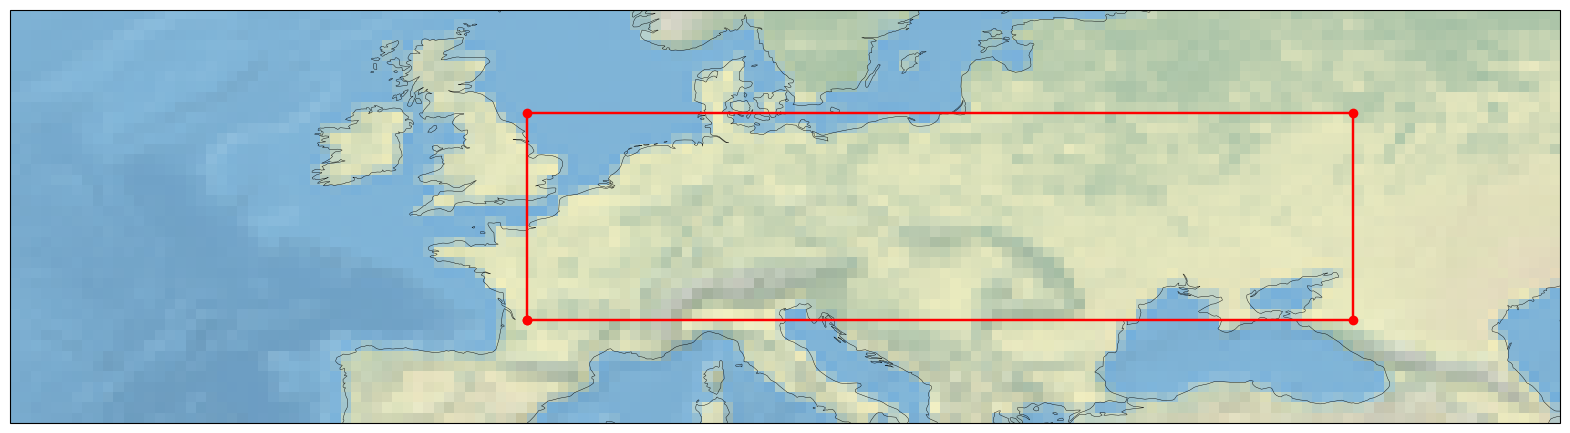

In [6]:
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.stock_img()
ax.coastlines()
ax.set_extent([-25, 50, 40, 60],crs=ccrs.PlateCarree())
lon = ERA5.longitude
lat = ERA5.latitude
longitudes = [lon[0], lon[-1], lon[-1], lon[0], lon[0]]
latitidues = [lat[-1], lat[-1], lat[0], lat[0], lat[-1]]
ax.plot(longitudes, latitidues, marker='o', color='red', transform=ccrs.PlateCarree());

(seasonal_seasonal-original-single-levels_resolution_q08:section-2)=
### 2. Debiasing

In [7]:
tas_max_hindcast_0 = da_hindcast["mx2t24"].isel(realization=0)
tas_min_hindcast_0 = da_hindcast["mn2t24"].isel(realization=0)

In [8]:
tas_max_hindcast = da_hindcast["mx2t24"]
tas_min_hindcast = da_hindcast["mn2t24"]

In [9]:
tas_max_0 = da_max_min["mx2t24"].isel(realization=0)
tas_min_0 = da_max_min["mn2t24"].isel(realization=0)

In [10]:
tas_max = da_max_min["mx2t24"]
tas_min = da_max_min["mn2t24"]

In [11]:
debiaser_min = CDFt.from_variable("tasmin",running_window_mode=False)
debiaser_max = CDFt.from_variable("tasmax",running_window_mode=False)

In [12]:
min_debiased = debiaser_min.apply(ERA5.t2m_min.values, tas_min_hindcast_0.values, tas_min_0.values,time_obs=ERA5.t2m_min.time,time_cm_hist=tas_min_hindcast_0.time,time_cm_future=tas_min_0.time)

/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains values outside the reasonable physical range of [100, 400] for the variable: Daily minimum near-surface air temperature. This might be due to different units of to data problems. It is recommended to check the input.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_hist contains values outside the reasonable physical range of [100, 400] for the variable: Daily minimum near-surface air temperature. This might be due to different units of to data problems. It is recommended to check the input.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_future contains values outside the reasonable physical range of [100

In [13]:
min_bias = tas_min_0 - min_debiased

In [14]:
max_debiased = debiaser_max.apply(ERA5.t2m_max.values, tas_max_hindcast_0.values, tas_max_0.values,time_obs=ERA5.t2m_max.time,time_cm_hist=tas_max_hindcast_0.time,time_cm_future=tas_max_0.time)

/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains values outside the reasonable physical range of [100, 400] for the variable: Daily maximum near-surface air temperature. This might be due to different units of to data problems. It is recommended to check the input.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_hist contains values outside the reasonable physical range of [100, 400] for the variable: Daily maximum near-surface air temperature. This might be due to different units of to data problems. It is recommended to check the input.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/data/common/miniforge3/envs/wp3/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: cm_future contains values outside the reasonable physical range of [100

In [15]:
max_bias = tas_max_0 - max_debiased

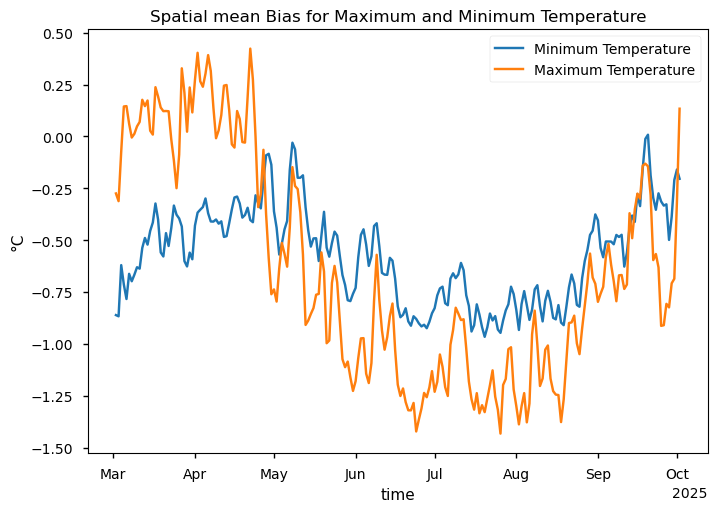

In [16]:
diagnostics.spatial_weighted_mean(min_bias).plot(label="Minimum Temperature");
diagnostics.spatial_weighted_mean(max_bias).plot(label="Maximum Temperature");
plt.title("Spatial mean Bias for Maximum and Minimum Temperature")
plt.ylabel(min_bias.units)
plt.legend()
plt.show()

Effect of debiasing on the spatial mean for minimum and maximum temperature, the biggest bias in both max and min temperature is a cold bias during summer, but generally the biased forecast is too cold. So removing this cold bias would make the forecast warmer, especially during summer months.

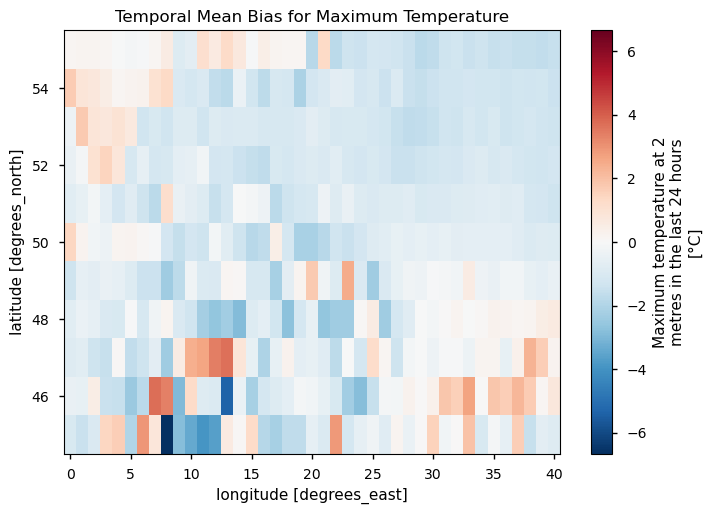

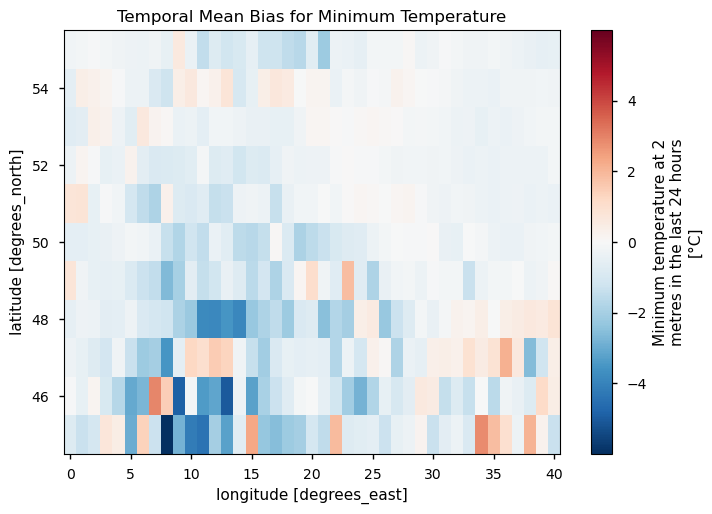

In [17]:
(max_bias).mean("time").plot(y="latitude",cmap="RdBu_r");
plt.title("Temporal Mean Bias for Maximum Temperature")
plt.show()
(min_bias).mean("time").plot(y="latitude",cmap="RdBu_r");
plt.title("Temporal Mean Bias for Minimum Temperature")
plt.show()

Effect on debiasing temporally shows that most of the bias is from the Alps, which has a prominent cold bias in the minimum temperature, but also a slight warm bias in the maximum temperature when averaged over the whole forecast period.

In [18]:
da_max_min["max_debiased"] = da_max_min["mx2t24"] - max_bias
da_max_min["min_debiased"] = da_max_min["mn2t24"] - max_bias

In [19]:
tas_max_forecast = da_max_min["max_debiased"]
tas_min_forecast = da_max_min["min_debiased"]

(seasonal_seasonal-original-single-levels_resolution_q08:section-3)=
### 3. Temperature trends year to year

In [20]:
years = range(1981,2016)
month = 4
month_label = {3:"March",4:"April",5:"May",6:"June",7:"July",8:"August"}

min_era5 = interannual_variability(years,ERA5.t2m_min,month)
max_era5 = interannual_variability(years,ERA5.t2m_max,month)

ensemble_min = []
ensemble_max = []
for member in da_hindcast.realization.values:
    ensemble_min.append(interannual_variability(years,tas_min_hindcast.sel(realization=member),month))
    ensemble_max.append(interannual_variability(years,tas_max_hindcast.sel(realization=member),month))

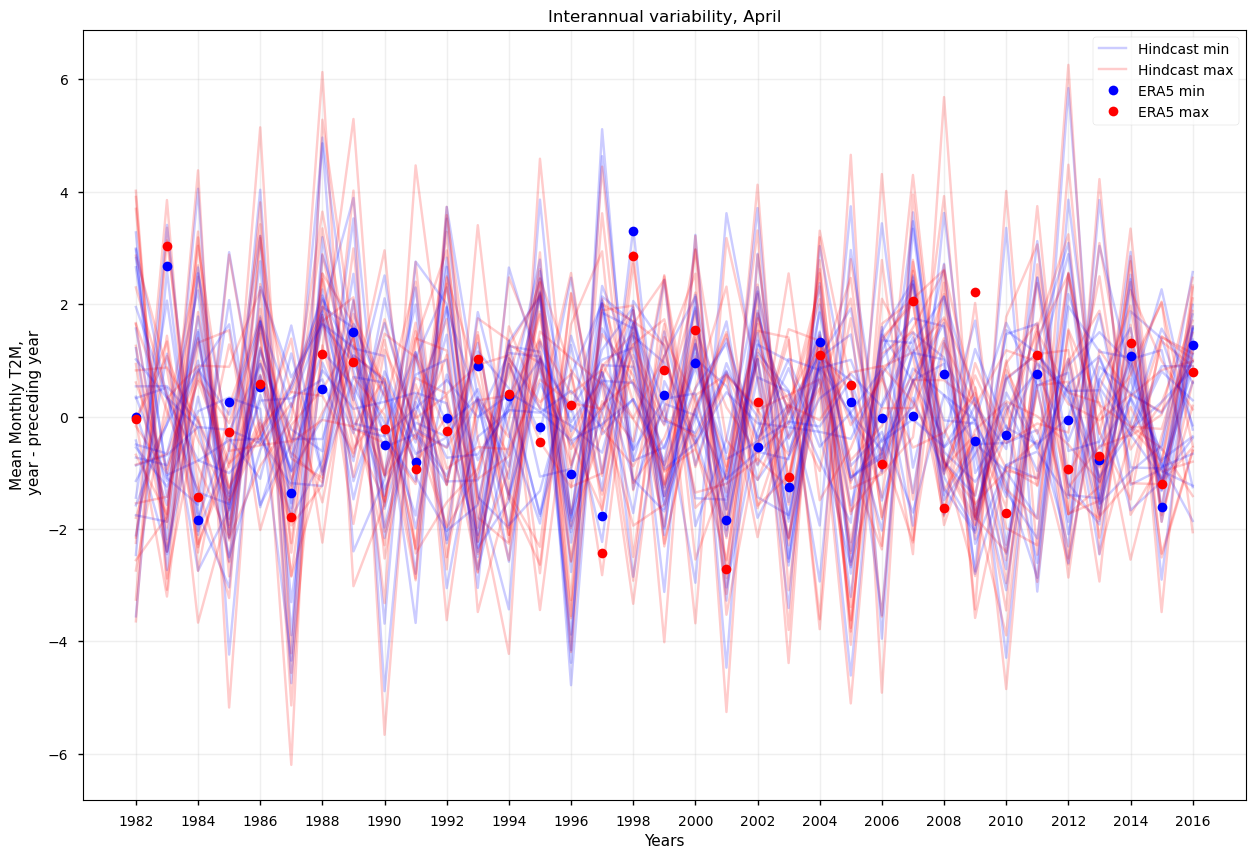

In [21]:
x_years = np.array(years)+1
fig = plt.figure(figsize=(15,10))
for member in da_hindcast.realization.values:
    plt.plot(x_years,ensemble_min[member],color='blue',label="Hindcast min",alpha=0.2)
    plt.plot(x_years,ensemble_max[member],color='red',label="Hindcast max",alpha=0.2)

plt.plot(x_years,min_era5,'bo',label = "ERA5 min")
plt.plot(x_years,max_era5,'ro',label = "ERA5 max")

plt.title(f"Interannual variability, {month_label[month]}")
plt.ylabel("Mean Monthly T2M,\n year - preceding year")
plt.xlabel("Years")
plt.xticks(x_years[::2])
plt.grid(alpha=0.2)
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys());

No clear trend in the interannual variability for the plant month.

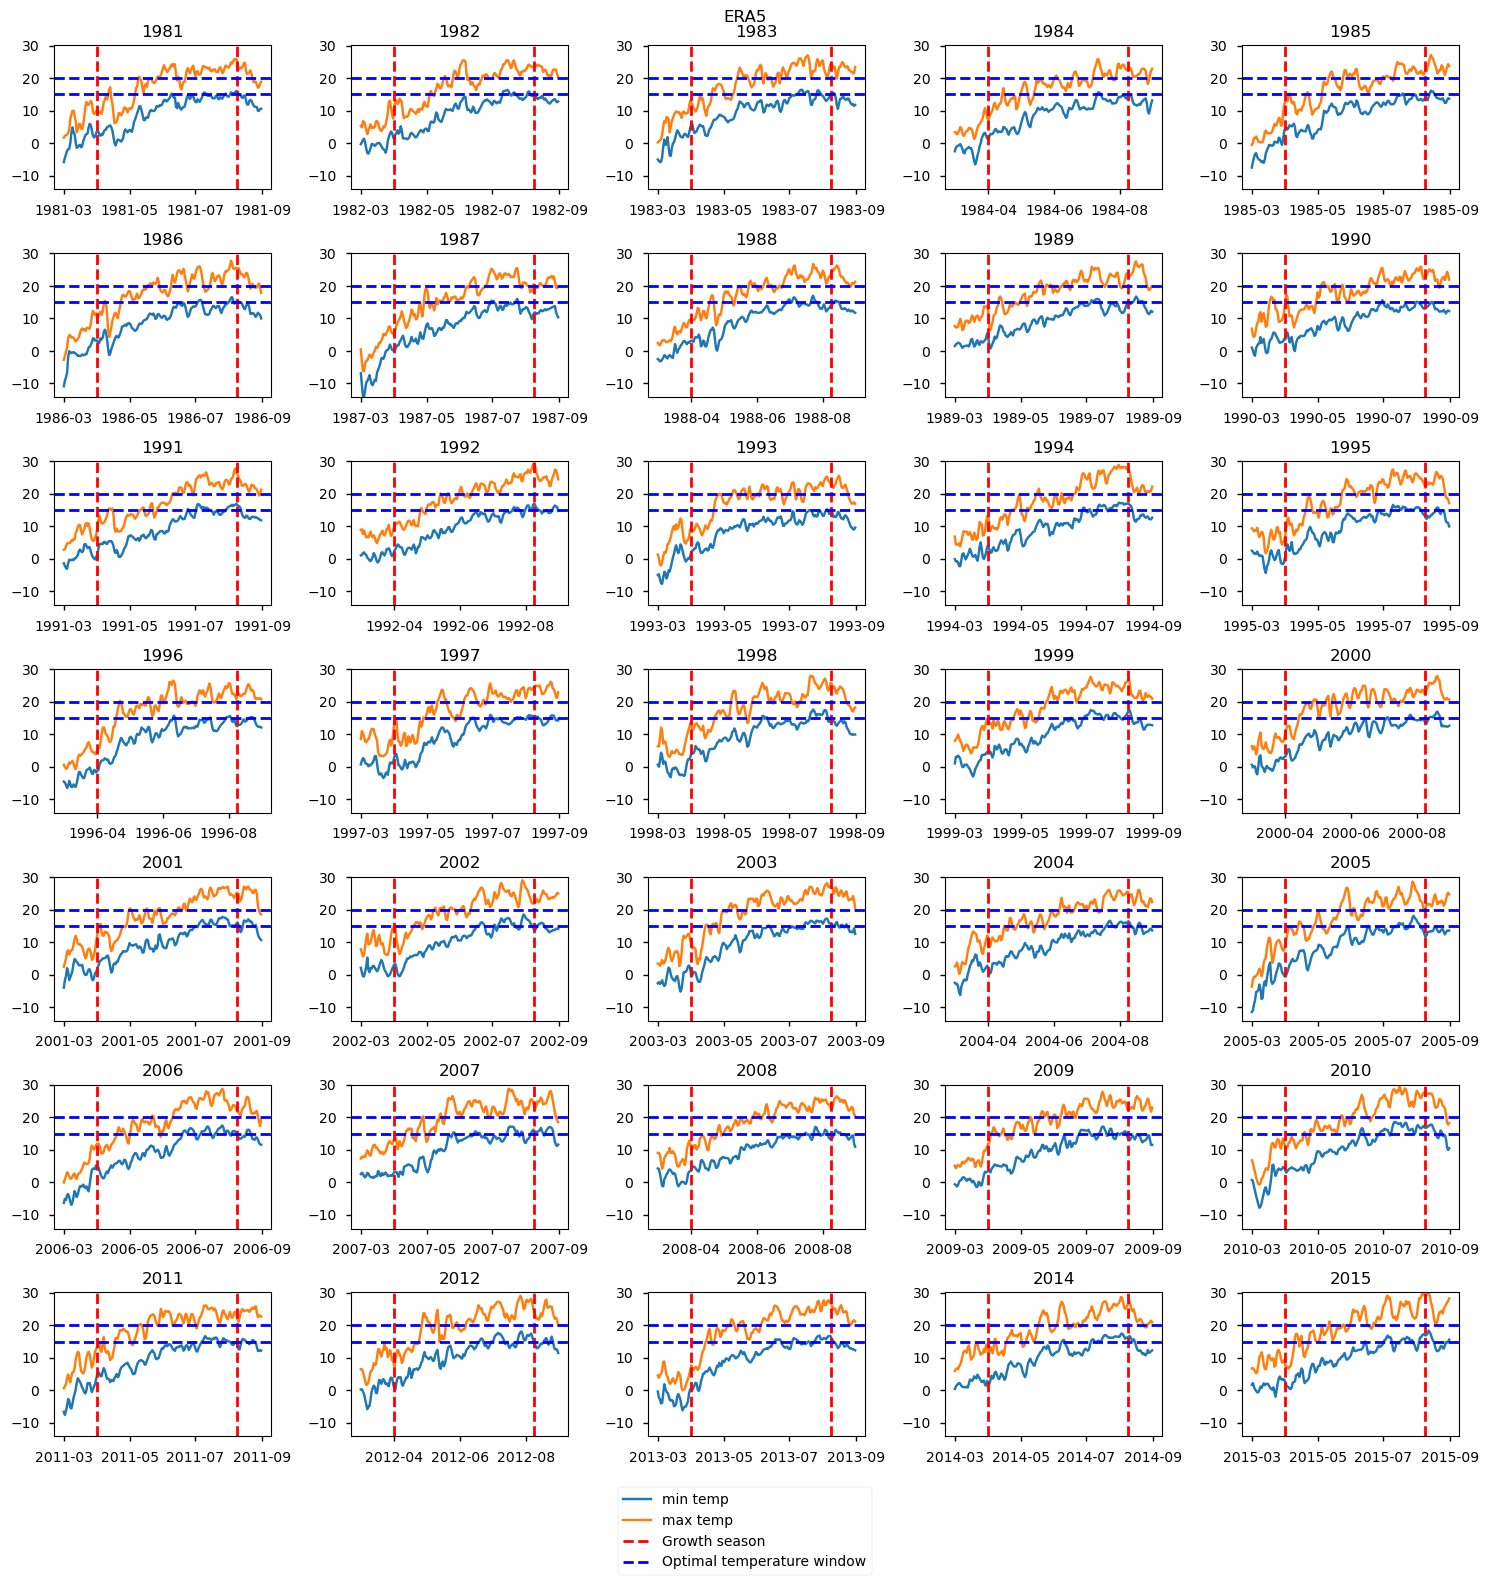

In [22]:
area_ERA5 = diagnostics.spatial_weighted_mean(ERA5)
plot_years(years, area_ERA5, 5, growth_time,"ERA5")

Some detectable increase in temperature window over time, moreso an increase in the maximum temperature. However it is difficult to draw any solid conclusions since there is quite a lot of variability between years.

In [23]:
hindcast_area_max =  diagnostics.spatial_weighted_mean(tas_max_hindcast)
hindcast_area_min =  diagnostics.spatial_weighted_mean(tas_min_hindcast)

In [24]:
min_less_than, members_less_min = count_less_than(hindcast_area_min,years,plant_month,growth_time,min_growing_temp,True)
min_greater_than, members_greater_min = count_greater_than(hindcast_area_min,years,plant_month,growth_time,max_growing_temp,True)

max_less_than, members_less_max = count_less_than(hindcast_area_max,years,plant_month,growth_time,min_growing_temp,True)
max_greater_than, members_greater_max = count_greater_than(hindcast_area_max,years,plant_month,growth_time,max_growing_temp,True)

era5_min_less_than, ignore = count_less_than(area_ERA5.t2m_min,years,plant_month,growth_time,min_growing_temp,False)
era5_min_greater_than, ignore = count_greater_than(area_ERA5.t2m_min,years,plant_month,growth_time,max_growing_temp,False)

era5_max_less_than, members_less_max = count_less_than(area_ERA5.t2m_max,years,plant_month,growth_time,min_growing_temp,False)
era5_max_greater_than, members_greater_max = count_greater_than(area_ERA5.t2m_max,years,plant_month,growth_time,max_growing_temp,False)

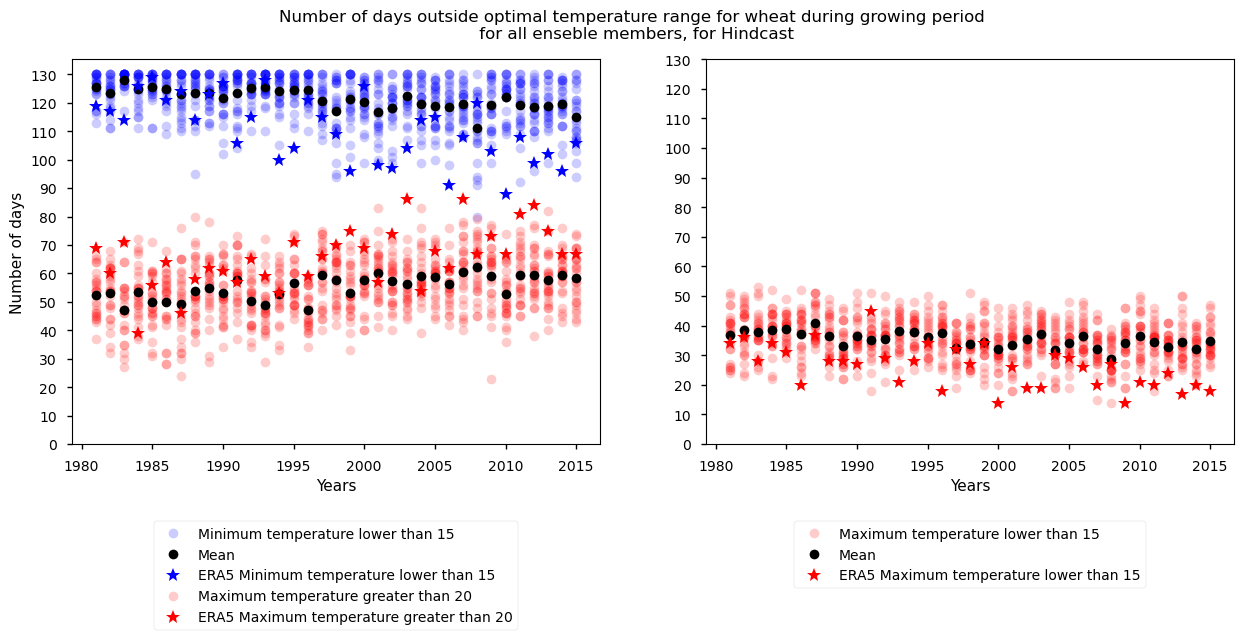

In [25]:
fig = plt.figure(figsize=(15,5))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
for year in years:
    idx = years.index(year)
    min_less_days = min_less_than[idx]
    max_greater_days = max_greater_than[idx]
    
    era5_min_less_days = era5_min_less_than[idx]
    era5_max_greater_days = era5_max_greater_than[idx]

    max_less_days = max_less_than[idx]
    min_greater_days = min_greater_than[idx]

    era5_max_less_days = era5_max_less_than[idx]
    era5_min_greater_days = era5_min_greater_than[idx]

    if np.sum(min_less_days) != 0:
        ax1.plot(year,min_less_days.reshape(1,min_less_days.shape[0]),marker="o",
             label=f"Minimum temperature lower than {min_growing_temp}",color="b",linestyle='none',alpha=0.2)
        ax1.plot(year,np.mean(min_less_days),marker="o",color="k",label="Mean",linestyle='none')
        ax1.plot(year,era5_min_less_days,marker="*",color="b",label=f"ERA5 Minimum temperature lower than {min_growing_temp}",linestyle='none',markeredgecolor='k',markersize=10)


    if np.sum(max_greater_days) != 0:
        ax1.plot(year,max_greater_days.reshape(1,min_less_days.shape[0]),marker="o",
             label=f"Maximum temperature greater than {max_growing_temp}",color="r",linestyle='none',alpha=0.2)
        ax1.plot(year,np.mean(max_greater_days),marker="o",color="k",label="Mean",linestyle='none')
        ax1.plot(year,era5_max_greater_days,marker="*",color="r",label=f"ERA5 Maximum temperature greater than {max_growing_temp}",linestyle='none',markeredgecolor='k',markersize=10)

    if np.sum(max_less_days) != 0:
        ax2.plot(year,max_less_days.reshape(1,max_less_days.shape[0]),marker="o",
             label=f"Maximum temperature lower than {min_growing_temp}",color="r",linestyle='none',alpha=0.2)
        ax2.plot(year,np.mean(max_less_days),marker="o",color="k",label="Mean",linestyle='none')
        ax2.plot(year,era5_max_less_days,marker="*",color="r",label=f"ERA5 Maximum temperature lower than {min_growing_temp}",linestyle='none',markeredgecolor='k',markersize=10)

    if np.sum(min_greater_days) != 0:
        ax2.plot(year,max_less_days.reshape(1,max_less_days.shape[0]),marker="o",
             label=f"Minimum temperature greater than {max_growing_temp}",color="b",linestyle='none',alpha=0.2)    
        ax2.plot(year,np.mean(min_greater_days),marker="o",color="k",label="Mean",linestyle='none')
        ax2.plot(year,era5_min_greater_days,marker="*",color="b",label=f"ERA5 Minimum temperature greater than {max_growing_temp}",linestyle='none',markeredgecolor='k',markersize=10)
    
ax1.set_xlabel("Years")
ax1.set_ylabel("Number of days")

ax2.set_xlabel("Years")

handles, labels = ax1.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax1.legend(unique.values(), unique.keys(),bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0);

handles, labels = ax2.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax2.legend(unique.values(), unique.keys(),bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0);

ax1.set_yticks(list(range(0,growth_time.days+1,10)))
ax2.set_yticks(list(range(0,growth_time.days+1,10)))

fig.suptitle("Number of days outside optimal temperature range for wheat during growing period \n for all enseble members, for Hindcast")
plt.show()

Faint increase in mean number of days where the maximum temperature is greater than 20 degrees, and a faint decrease in the number of days where the minimum temperature is below 15, this is also coherent with a visible decrease in the number of days where the maximum temperature is below 15. Although during this period there were no days counted during any year that the minimum temperature was greater than 20 degrees. 

(seasonal_seasonal-original-single-levels_resolution_q08:section-4)=
### 4. Plot the temperature data with growth season and optimal temperature window

Computing the area max, min, and mean for the future growth season.

In [26]:
area_mean_max = diagnostics.spatial_weighted_mean(tas_max_forecast)
area_mean_min = diagnostics.spatial_weighted_mean(tas_min_forecast)

Plotting the maximum and minimum temperatures against the growth season and optimal temperature window for the chosen crop.

In [27]:
max_sum = 0
min_sum = 0
hindcast_max_max = -1000
hindcast_max_min = 1000
hindcast_min_max = -1000
hindcast_min_min = 1000

for year in years:
    selection = pd.date_range(str(year)+"-03",str(year)+"-10", inclusive = "left")
    hindcast_max_values = (hindcast_area_max.sel(time=selection,method="nearest")).values
    hindcast_max_max = np.where(hindcast_max_max < hindcast_max_values , hindcast_max_values, hindcast_max_max)
    hindcast_max_min = np.where(hindcast_max_min > hindcast_max_values , hindcast_max_values, hindcast_max_min)
    max_sum += hindcast_max_values
    hindcast_min_values = (hindcast_area_min.sel(time=selection,method="nearest")).values
    hindcast_min_max = np.where(hindcast_min_max < hindcast_min_values , hindcast_min_values, hindcast_min_max)
    hindcast_min_min = np.where(hindcast_min_min > hindcast_min_values , hindcast_min_values, hindcast_min_min)
    min_sum += hindcast_min_values

hindcast_max_mean = max_sum / len(years)
hindcast_min_mean = min_sum / len(years)
hindcast_max_max = np.max(hindcast_max_max,0)
hindcast_max_min = np.min(hindcast_max_min,0)
hindcast_min_max = np.max(hindcast_min_max,0)
hindcast_min_min = np.min(hindcast_min_min,0)

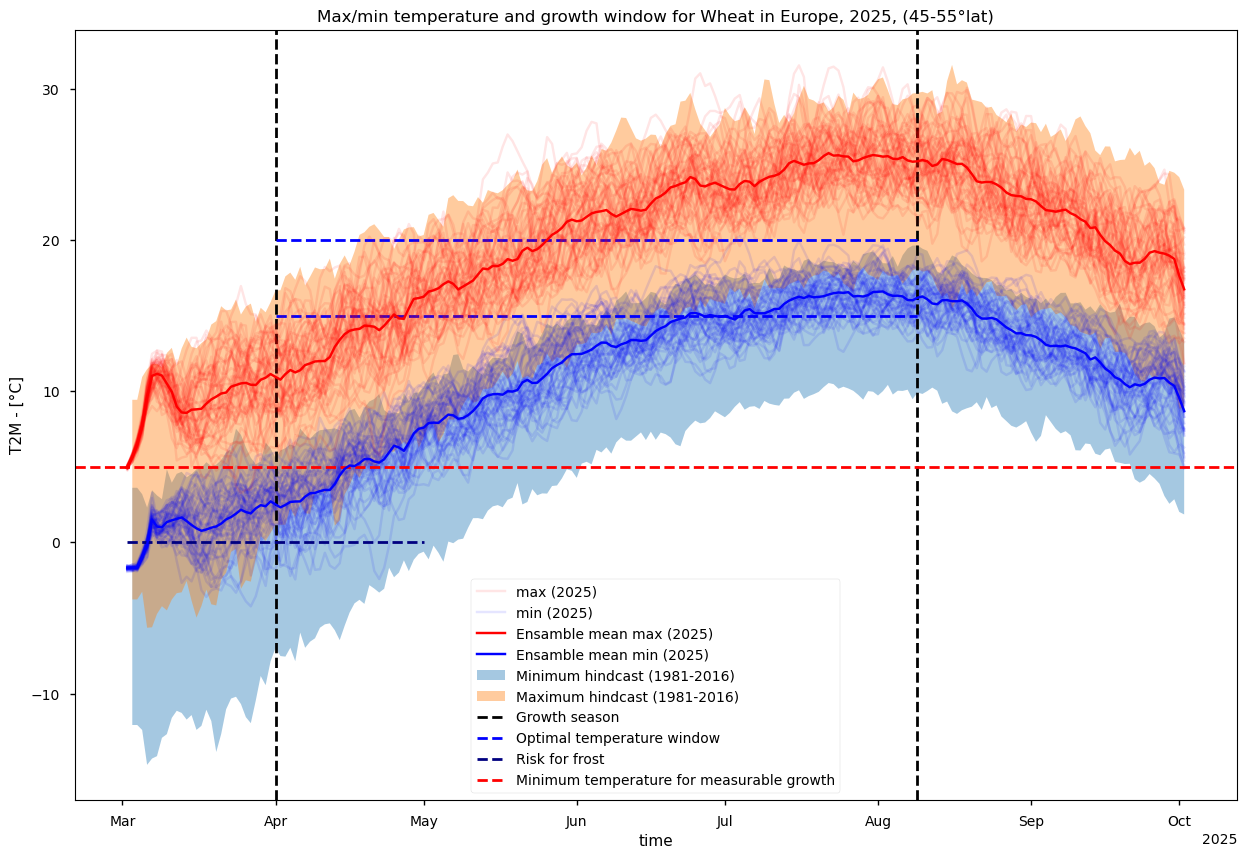

In [28]:
fig = plt.figure(figsize=(15,10))

start_month = get_plant_month(2025, plant_month)
end_month = start_month + growth_time

area_mean_max.plot.line(hue="realization", c="r", alpha=0.1, label="max (2025)",zorder=3)
area_mean_min.plot.line(hue="realization", c="b", alpha=0.1, label="min (2025)",zorder=2)
area_mean_max.mean(dim="realization").plot.line(c="r",label="Ensamble mean max (2025)",zorder=4)
area_mean_min.mean(dim="realization").plot.line(c="b",label="Ensamble mean min (2025)",zorder=4)
ax = plt.gca()
ax.fill_between(area_mean_max.time[1:], hindcast_min_min, hindcast_min_max,zorder=1, alpha=.4, label="Minimum hindcast (1981-2016)")
ax.fill_between(area_mean_max.time[1:], hindcast_max_min, hindcast_max_max,zorder=1, alpha=.4, label="Maximum hindcast (1981-2016)")

ax.axvline(x=start_month, color='black', linestyle='--', linewidth=2,label="Growth season")
ax.axvline(x=end_month, color='black', linestyle='--', linewidth=2)

ax.hlines(xmin=start_month, xmax=end_month, y=max_growing_temp, color='blue', linestyle='--', linewidth=2, label = "Optimal temperature window")
ax.hlines(xmin=start_month, xmax=end_month, y=min_growing_temp, color='blue', linestyle='--', linewidth=2)
ax.hlines(xmin=area_mean_max.time[0], xmax=area_mean_max.time[0]+ pd.Timedelta(60,"D"), y=frost_risk_temp, color='navy', linestyle='--', linewidth=2,label="Risk for frost")

ax.axhline(y=5, color='red', linestyle='--', linewidth=2, label = "Minimum temperature for measurable growth")
plt.title("Max/min temperature and growth window for Wheat in Europe, 2025, (45-55°lat)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylabel("T2M - [°C]")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys());

For the 2025 season, looking at the growth parameters for spring wheat with the planting month in April, the forecast has several ensemble members that remain within the optimal growth window for most of the period. However, the ensemble means for both minimum and maximum temperatures fall outside of the window for a large part of the period. 

Very few ensemble members fall below the frost risk threshold for this year, indicating that April is a good month to plant in that regard. 

Overall the results indicate that the maximum temperature is higher than the optimal temperature for a large part of the period, starting towards the end of may in the ensemble mean. The interval between the minimum and maximum temperature also looks to be fairly consistent. 

From this plot we can draw the conclusion that it is likely that higher temperatures towards the middle to end of the growth period might have an impact on the growth rate and yield, but exactly what impact is difficult to quantify. 

(seasonal_seasonal-original-single-levels_resolution_q08:section-5)=
### 5. Discussion

* The use case of seasonal forecasts for planning in agriculture
* Lack of visible trend from year to year in conditions surrounding optimal growth for spring wheat for this region and setup 
* Conclusion about relationships between min/max temperature (too warm days, too cold nights, not cold enough nights etc.) on crop growth
* Elaboration on key limitations, like restricted region, time period, ignoring other parameters such as precipitation - capacity to water/soil moisture

## ℹ️ If you want to know more

### Key resources

 * Seasonal forecast daily and subdaily data on single levels: [10.24381/cds.181d637e](https://doi.org/10.24381/cds.181d637e)

### Code libraries used:
 * [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)
 * xarray
 * numpy
 * matplotlib
 * ibicus ([Spuler, et al. (2024) \[2\]](https://doi.org/10.5194/gmd-17-1249-2024))

### References

[[1]](https://doi.org/10.1016/j.agrformet.2007.05.002) Lobell, David B.: Changes in diurnal temperature range and national cereal yields, Agricultural and Forest Meteorology, 145, 229-238, https://doi.org/10.1016/j.agrformet.2007.05.002, 2007

[[2]](https://doi.org/10.5194/gmd-17-1249-2024) Spuler, F. R., Wessel, J. B., Comyn-Platt, E., Varndell, J., and Cagnazzo, C.: ibicus: a new open-source Python package and comprehensive interface for statistical bias adjustment and evaluation in climate modelling (v1.0.1), Geosci. Model Dev., 17, 1249–1269, https://doi.org/10.5194/gmd-17-1249-2024, 2024.

[[3]](https://www.fao.org/land-water/databases-and-software/crop-information/wheat/en/) Fao.org Food and Agriculture Organization of the United Nations. Available at: https://www.fao.org/land-water/databases-and-software/crop-information/wheat/en/ (Accessed: 28 November 2025). 